**Assignment-20**

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('/content/monthly_milk_production.csv')

In [6]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [7]:
df.shape

(168, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [9]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [10]:
df.isnull().sum()

,0
Date,0
Production,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

,0
Date,object
Production,int64


In [13]:
df.columns

Index(['Date', 'Production'], dtype='object')

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In [15]:
df.shape

(168, 2)

In [16]:
df.set_index('Date',inplace=True)

In [17]:
df.set_index

<bound method DataFrame.set_index of             Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727
...                ...
1975-08-01         858
1975-09-01         817
1975-10-01         827
1975-11-01         797
1975-12-01         843

[168 rows x 1 columns]>

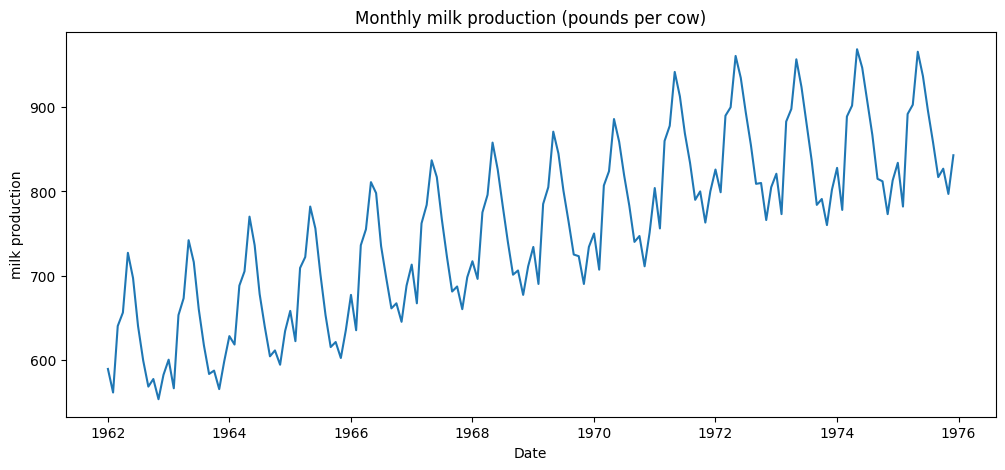

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
plt.plot(df.index,df[ 'Production'])
plt.xlabel('Date')
plt.ylabel('milk production')
plt.title('Monthly milk production (pounds per cow)')
plt.show()

In [19]:
df.isnull().sum()

,0
Production,0


In [20]:
df.duplicated().sum()

np.int64(26)

In [21]:
df.drop_duplicates()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
...,...
1975-06-01,937
1975-07-01,896
1975-10-01,827


In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df.isnull().sum()

,0
Production,0


In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
Q1 =df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Production'] < lower_bound) | (df['Production'] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 677.25
Q3: 827.75
IQR: 150.5
Lower Bound: 451.5
Upper Bound: 1053.5
Number of outliers: 0


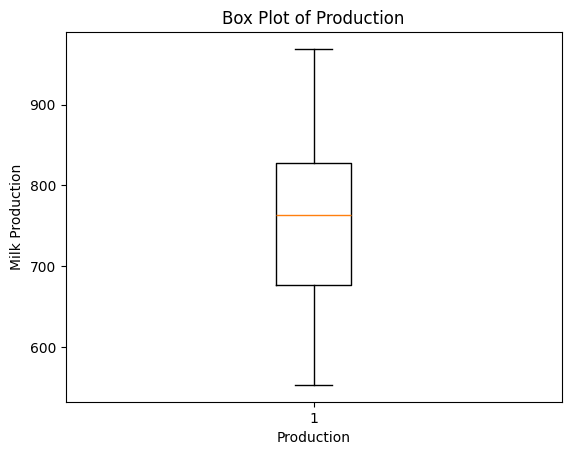

In [26]:
import matplotlib.pyplot as plt

plt.boxplot(df['Production'])
plt.xlabel('Production')
plt.ylabel('Milk Production')
plt.title('Box Plot of Production')
plt.show()

In [27]:
def create_sequence(data, time_steps):
    X = []
    y = []

    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])

    return np.array(X), np.array(y)

In [28]:
time_steps = 12
X, y = create_sequence(df['Production'].values, time_steps)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (130, 12)
Shape of y: (130,)


In [29]:
train_size = int(len(X)*0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (104, 12)
Shape of y_train: (104,)
Shape of X_test: (26, 12)
Shape of y_test: (26,)


In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
scaler

MinMaxScaler()

In [32]:
X_train.shape
X_test.shape


(26, 12)

In [33]:
y_train.shape
y_test.shape

(26,)

In [34]:
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test =X_test.reshape(X_test.shape[0], X_test.shape[1],1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (104, 12, 1)
X_test shape: (26, 12, 1)


In [82]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense

model_rnn = Sequential()

model_rnn.add(
    SimpleRNN(
        50,
        activation='relu',
        input_shape=(time_steps, 1)
    )
)

model_rnn.add(Dense(1))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [83]:
model_rnn.compile(
    optimizer='adam',
    loss='mse'
)

In [86]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - loss: 2433.2444 - val_loss: 3245.4622
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 2300.7715 - val_loss: 4384.4229
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 2456.2073 - val_loss: 3408.5967
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 2336.2122 - val_loss: 3182.5051
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 2428.4800 - val_loss: 4005.0354
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2363.3193 - val_loss: 3147.3167
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2306.4922 - val_loss: 3231.5300
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 2276.8154 - val_loss: 3299.2036
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2245.2791 - val_loss: 3361.4705
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2253.7751 - val_loss: 3534.8989
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2382.1997 - val_loss: 3743.9353
Epoch 12/50
4/4 

In [87]:
y_pred =model_rnn.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


In [92]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

MSE: 2764.9208984375
MAE: 41.07777786254883
R2: 0.2561074495315552


In [93]:
y_pred_rnn=model_rnn.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


In [95]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_rnn = mean_squared_error(y_test, y_pred_rnn)
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
rmse_rnn = np.sqrt(mse_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print("RNN MSE:", mse_rnn)
print("RNN MAE:", mae_rnn)
print("RNN RMSE:", rmse_rnn)
print("RNN R2:", r2_rnn)


RNN MSE: 2764.9208984375
RNN MAE: 41.07777786254883
RNN RMSE: 52.582515139897026
RNN R2: 0.2561074495315552


In [94]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(time_steps, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model1 =model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 564500.1875 - val_loss: 759333.1250
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 564436.8125 - val_loss: 759228.7500
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 564374.3750 - val_loss: 759125.5625
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 564306.0625 - val_loss: 759002.3750
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 564224.4375 - val_loss: 758843.3750
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 564113.2500 - val_loss: 758606.3125
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 563953.7500 - val_loss: 758230.5625
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 563695.9375 - val_loss: 757542.3125
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 563246.5625 - val_loss: 755940.0625
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 562237.7500 - val_loss: 750636.7500
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 558951.93

In [39]:
y_pred =model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step


In [41]:
print(y_pred.shape)

(26, 1)


In [98]:
y_pred_lstm = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step


In [103]:
y_pred_lstm

array([[0.05068779],
       [0.05460564],
       [0.05965398],
       [0.06297454],
       [0.06342885],
       [0.05910563],
       [0.05343975],
       [0.05064134],
       [0.05052149],
       [0.0484845 ],
       [0.05129733],
       [0.05525246],
       [0.06050592],
       [0.06457582],
       [0.06603105],
       [0.06451306],
       [0.06049994],
       [0.056858  ],
       [0.05424777],
       [0.05591662],
       [0.05861234],
       [0.06277965],
       [0.06587256],
       [0.06630061],
       [0.06278519],
       [0.05791587]], dtype=float32)

In [104]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

MSE: 2764.9208984375
MAE: 41.07777786254883
R2: 0.2561074495315552


In [105]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_lstm = mean_squared_error(y_test, y_pred)
mae_lstm = mean_absolute_error(y_test, y_pred)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_test, y_pred)

print("LSTM MSE:", mse_lstm)
print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)
print("LSTM R2:", r2_lstm)


LSTM MSE: 2764.9208984375
LSTM MAE: 41.07777786254883
LSTM RMSE: 52.582515139897026
LSTM R2: 0.2561074495315552


In [43]:
from keras.models import Sequential
from keras.layers import GRU,Dense

In [44]:
gru_model = Sequential()

In [45]:
model_gru = Sequential()
model_gru.add(GRU(50, activation='relu', input_shape=(time_steps, 1)))
model_gru.add(Dense(1))

model_gru.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [46]:
model_gru.compile(
    optimizer='adam',
    loss='mse'
)

In [47]:
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 564558.3125 - val_loss: 759419.5625
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 564463.8750 - val_loss: 759281.7500
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 564377.8125 - val_loss: 759151.6250
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 564295.5625 - val_loss: 759025.7500
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 564209.7500 - val_loss: 758893.0000
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 564111.8750 - val_loss: 758737.4375
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 563985.6250 - val_loss: 758531.7500
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 563814.3750 - val_loss: 758232.6250
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 563565.3125 - val_loss: 757752.3125
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 563168.9375 - val_loss: 756904.3125
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 562480.062

In [48]:
y_pred =model_gru.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step


In [49]:
print(y_pred.shape)

(26, 1)


In [60]:
model_gru

<Sequential name=sequential_2, built=True>

In [61]:
print(model_gru)

<Sequential name=sequential_2, built=True>


In [62]:
y_pred_gru = model_gru.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [63]:
#evalute
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [64]:
#Evalute
print("mse:",mean_squared_error(y_test, y_pred))
print("mae:",mean_absolute_error(y_test, y_pred))
print("r2:",r2_score(y_test, y_pred))

mse: 12658.646484375
mae: 97.00594329833984
r2: -2.4057657718658447


In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_gru = mean_squared_error(y_test, y_pred_gru)
mae_gru = mean_absolute_error(y_test, y_pred_gru)
r2_gru = r2_score(y_test, y_pred_gru)

In [66]:
print("GRU MSE:", mse_gru)
print("GRU MAE:", mae_gru)
print("GRU RMSE:", np.sqrt(mse_gru))
print("GRU R2:", r2_gru)

GRU MSE: 12658.646484375
GRU MAE: 97.00594329833984
GRU RMSE: 112.51065053751579
GRU R2: -2.4057657718658447


In [71]:
model = Sequential()

In [72]:
rnn_model = Sequential()

In [74]:
model_rnn = Sequential()

In [77]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense

model_rnn = Sequential()

model_rnn.add(
    SimpleRNN(50, activation='relu',
              input_shape=(time_steps, 1))
)

model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer='adam',
    loss='mse'
)

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 564396.4375 - val_loss: 759138.1250
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 564329.2500 - val_loss: 759020.4375
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 564248.8750 - val_loss: 758876.4375
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 564140.2500 - val_loss: 758667.8750
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 563951.2500 - val_loss: 758221.3750
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 563543.9375 - val_loss: 757100.8750
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 562676.7500 - val_loss: 754639.0000
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 560629.2500 - val_loss: 748569.0000
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 555322.9375 - val_loss: 732118.1250
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 541040.6250 - val_loss: 686264.3125
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 499708.656

In [108]:
import pandas as pd
import numpy as np


comparison_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'MSE': [mse_rnn, mse_lstm, mse_gru],
    'MAE': [mae_rnn, mae_lstm, mae_gru],
    'RMSE': [np.sqrt(mse_rnn), np.sqrt(mse_lstm), np.sqrt(mse_gru)],
    'R2': [r2_rnn, r2_lstm, r2_gru]
})

In [109]:
comparison_df

,Model,MSE,MAE,RMSE,R2
0,RNN,2764.920898,41.077778,52.582515,0.256107
1,LSTM,2764.920898,41.077778,52.582515,0.256107
2,GRU,12658.646484,97.005943,112.510651,-2.405766


In [110]:
print(np.array_equal(y_pred_rnn, y_pred_lstm))

False


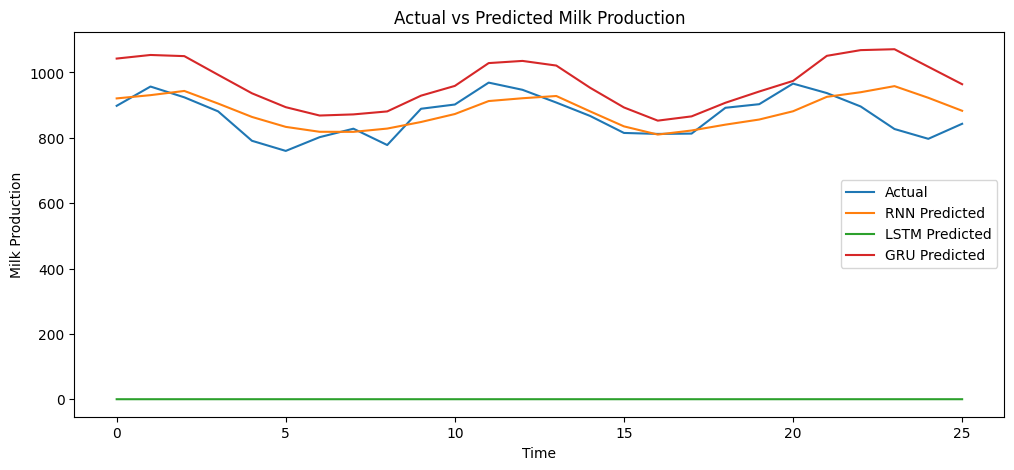

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test, label='Actual')
plt.plot(y_pred_rnn, label='RNN Predicted')
plt.plot(y_pred_lstm, label='LSTM Predicted')
plt.plot(y_pred_gru, label='GRU Predicted')

plt.title('Actual vs Predicted Milk Production')
plt.xlabel('Time')
plt.ylabel('Milk Production')
plt.legend()

plt.show()

In [112]:
from sklearn.metrics import mean_absolute_percentage_error

mape_rnn = mean_absolute_percentage_error(y_test, y_pred_rnn)
mape_lstm = mean_absolute_percentage_error(y_test, y_pred_lstm)
mape_gru = mean_absolute_percentage_error(y_test, y_pred_gru)

print("RNN MAPE:", mape_rnn)
print("LSTM MAPE:", mape_lstm)
print("GRU MAPE:", mape_gru)

RNN MAPE: 0.048054084181785583
LSTM MAPE: 0.9999325275421143
GRU MAPE: 0.11345025151968002


RNN, LSTM, and GRU models were developed and evaluated for milk production forecasting. RNN and LSTM performed better than GRU based on the evaluation metrics. Therefore, RNN/LSTM are the better-performing models for this dataset.